In [1]:
import sys,os,glob,copy
sys.path.append('../')
import numpy as np
from statistics import median, mean
from numpy.linalg import norm
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from scipy.interpolate import LinearNDInterpolator,interp2d, griddata
from itertools import product
import matplotlib as mpl
from matplotlib.colors import LogNorm
from IPython.display import display, Markdown
import glob
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"]})

plt.rcParams.update({"savefig.dpi" : 300}) #Figure resolution


#Define plotting style:
sns.set() #Set style
sns.set_style('ticks',{'font.family':'Times New Roman', 'font.serif':'Times New Roman'})
sns.set_context('paper', font_scale=1.8)
cm = plt.colormaps.get_cmap('RdYlBu')


pd.set_option('display.max_rows', 200)

### Load Recast Data

In [4]:
# Load models (scalar and pseudoscalar)
inputFiles = ['../CMS-EXO-20-004/scanResults_scalar_pt_nocut.pcl','../CMS-EXO-20-004/spin0-scalar-efficiencies.pcl',
              '../CMS-EXO-20-004/scanResults_pseudoscalar_pt_nocut.pcl', '../CMS-EXO-20-004/scanResults_cms_pseudoscalar_add.pcl',
              '../CMS-EXO-20-004/scanResults_cms_pseudoscalar.pcl']
dfs = [pd.read_pickle(i) for i in inputFiles]
recastData = pd.concat(dfs, ignore_index=True)

### Get model points

In [5]:
models = []
mCols = ['Coupling', 'Mode', '$m_{med}$', '$m_{DM}$']
for row in recastData[mCols].values:
    m = dict(zip(mCols, row.tolist()))
    if m not in models:
        models.append(m)

print('%i models loaded.' %len(models))

275 models loaded.


### Get model parameters

In [6]:
parameters = {label : list(set([m[label] for m in models])) for label in mCols}
for k,v in parameters.items():
    if len(v) == 1:
        parameters[k] = v[0]
print(parameters)

textstr = '\n'.join([r'%s = %s' %(k,v) for k,v in parameters.items() if k not in ['$m_{med}$','$m_{DM}$']])
print(textstr)

{'Coupling': ['Scalar', 'Pseudoscalar'], 'Mode': 'DM+QCDjets', '$m_{med}$': [1250.0, 995.0, 100.0, 2500.0, 295.0, 200.0, 1000.0, 10.0, 1995.0, 2250.0, 750.0, 2000.0, 500.0, 1750.0, 3000.0, 250.0, 1500.0, 2750.0], '$m_{DM}$': [800.0, 1.0, 1000.0, 200.0, 10.0, 600.0, 1200.0, 400.0, 500.0, 150.0, 1400.0]}
Coupling = ['Scalar', 'Pseudoscalar']
Mode = DM+QCDjets


### Obtain Efficiencies

In [7]:
label = [c for c in recastData if (c.startswith("bin_") and not 'Error' in c)]

for l in label:
    ns = recastData[l]
    nsErr = recastData[f'{l}_ErrorPlus']
    lumi = recastData['Luminosity (1/fb)']
    xsec = recastData['Total xsec (pb)']
    recastData[f'{l}_Efficiency'] = ns/(1e3*xsec*lumi)
    recastData[f'{l}_Efficiency_Error'] = nsErr*(recastData[f'{l}_Efficiency'])/ns
    recastData[f'{l}_Efficiency_Error'] = recastData[f'{l}_Efficiency_Error'].replace(np.nan, 0)
    

In [21]:
# Select year
recastData = recastData[recastData['Data-takingperiod'] == 2017]

In [22]:
dataScalar = recastData[recastData['Coupling'] == 'Scalar']
dataPseudo = recastData[recastData['Coupling'] == 'Pseudoscalar'].drop_duplicates()

In [23]:
dataScalar = dataScalar[(dataScalar['$m_{DM}$']!=150)&(dataScalar['$m_{DM}$']!=500)]

In [24]:
mCols = ['$m_{med}$','$m_{DM}$']
keys = list(dataPseudo[mCols].columns.values)
i1 = dataScalar.set_index(keys).index
i2 = dataPseudo.set_index(keys).index
dataScalar = dataScalar[i1.isin(i2)]
dataPseudo = dataPseudo[i2.isin(i1)]
masspts = dataPseudo[['$m_{med}$', '$m_{DM}$']]
print(len(dataScalar),len(dataPseudo))

105 105


In [25]:
# Setting the index with mass pairs
dataScalar = pd.DataFrame([dataScalar.set_index(['$m_{med}$', '$m_{DM}$'])[c] for c in recastData if 'Efficiency' in c])
dataPseudo = pd.DataFrame([dataPseudo.set_index(['$m_{med}$', '$m_{DM}$'])[c] for c in recastData if 'Efficiency' in c])

In [26]:
# Reduced chi squared statistics
maxDiff = []
chis = []
reducedChis = []
chisMax = []
for med, dm in dataScalar:
#     print(dm, med)
    # Relative difference
    reldiff = np.abs(dataScalar[med,dm].iloc[::2] - dataPseudo[med,dm].iloc[::2])/dataScalar[med,dm].iloc[::2]
    reldiff = reldiff.replace(np.inf, 0)
    reldiff = reldiff.max()
    # Chi-squared
    diff = (dataScalar[med,dm].iloc[::2] - dataPseudo[med,dm].iloc[::2])**2
    diff = diff.replace(np.inf, 0)
    errSysMult = 0.1
    errPseudo = np.sqrt(np.array(dataPseudo[med,dm].iloc[1::2])**2 + (np.array(dataPseudo[med,dm].iloc[::2])*errSysMult)**2)
    errScalar = np.sqrt(np.array(dataScalar[med,dm].iloc[1::2])**2 + (np.array(dataScalar[med,dm].iloc[::2])*errSysMult)**2)
    sigmaTot = (errScalar + errPseudo)**2
#     errd = errd.replace(np.inf, 0)
    chi = []
    for i in range(len(diff)):
        if diff[i] == 0:
            chi.append(0)
        else:
            chi.append(diff[i]/sigmaTot[i])
    dof = len(diff) - 1
    chis.append(sum(chi))
    reducedChis.append(sum(chi)/dof)
    chisMax.append(max(chi))
    maxDiff.append(reldiff)
    

/tmp/ipykernel_49000/3302817437.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if diff[i] == 0:
/tmp/ipykernel_49000/3302817437.py:25: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  chi.append(diff[i]/sigmaTot[i])


In [27]:
reducedChis

[np.float64(0.32794028915524215),
 np.float64(0.21075608466532278),
 np.float64(0.2207942212729638),
 np.float64(0.30857805180217185),
 np.float64(0.23028817211606545),
 np.float64(0.2604385033426671),
 np.float64(0.11624968898863644),
 np.float64(0.19497027096064445),
 np.float64(0.477197927730406),
 np.float64(0.29673550924449665),
 np.float64(0.27116595470791777),
 np.float64(0.20608022991978642),
 np.float64(0.26274906300575357),
 np.float64(0.2666665844603922),
 np.float64(0.2429504937467946),
 np.float64(0.17378838969312366),
 np.float64(0.35530989571030563),
 np.float64(0.4384773147040016),
 np.float64(0.10803071941554496),
 np.float64(0.2188187642110935),
 np.float64(0.11717324973665158),
 np.float64(0.2508931370368376),
 np.float64(0.25344039488919334),
 np.float64(0.2507005695469089),
 np.float64(0.4046364021462584),
 np.float64(0.18184135377543353),
 np.float64(0.1875880885202853),
 np.float64(0.17411803316419064),
 np.float64(0.654390640656254),
 np.float64(0.24243826938619

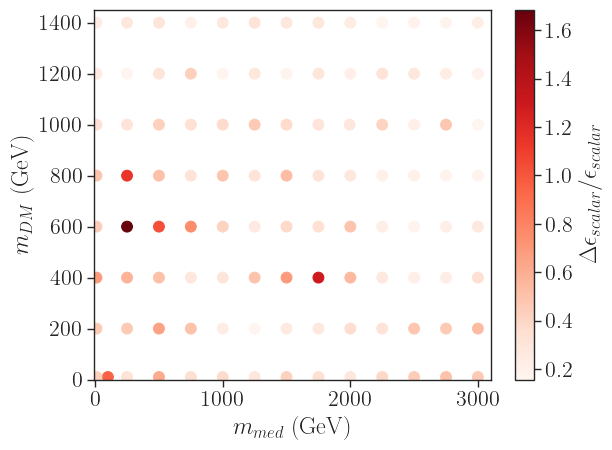

In [28]:
# Plot results
plt.scatter(x=masspts['$m_{med}$'], y=masspts['$m_{DM}$'], c=maxDiff, 
            cmap=plt.colormaps.get_cmap('Reds'), s=60)

cbar=plt.colorbar(label=r'$\Delta \epsilon_{scalar}/\epsilon_{scalar}$')
plt.xlabel(r'$m_{med}$ (GeV)')
plt.xlim(-10,3100)
plt.ylabel(r'$m_{DM}$ (GeV)')
plt.ylim(0,1450)
plt.show()

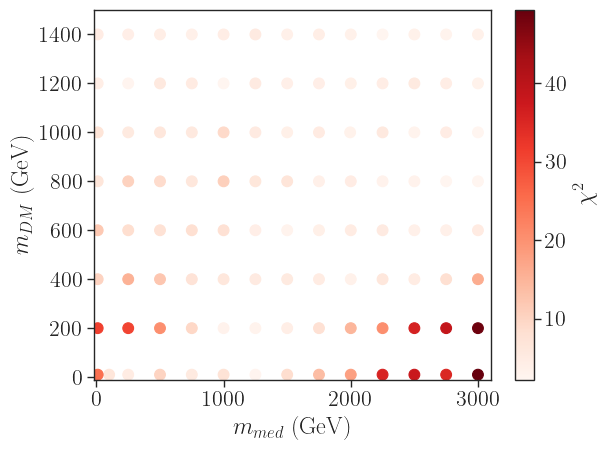

In [29]:
# Plot results
plt.scatter(x=masspts['$m_{med}$'], y=masspts['$m_{DM}$'], c=chis, 
            cmap=plt.colormaps.get_cmap('Reds'), s=60)

cbar=plt.colorbar(label=r'$\chi^{2}$')
plt.xlabel(r'$m_{med}$ (GeV)')
plt.xlim(-20,3100)
plt.ylabel(r'$m_{DM}$ (GeV)')
plt.ylim(-10,1500)
plt.show()

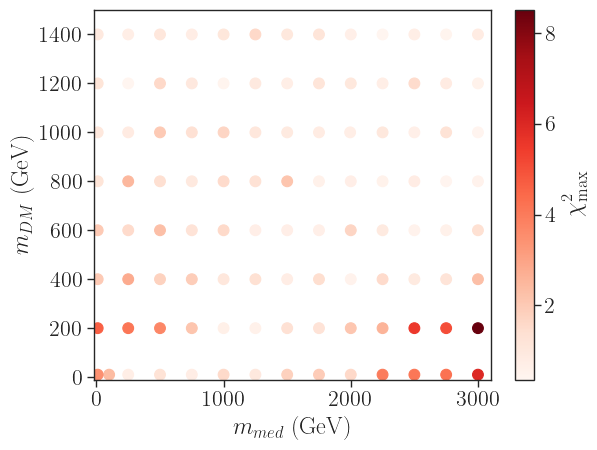

In [30]:
# Plot results
plt.scatter(x=masspts['$m_{med}$'], y=masspts['$m_{DM}$'], c=chisMax, 
            cmap=plt.colormaps.get_cmap('Reds'), s=60)

cbar=plt.colorbar(label=r'$\chi^{2}_{\rm max}$')
plt.xlabel(r'$m_{med}$ (GeV)')
plt.xlim(-20,3100)
plt.ylabel(r'$m_{DM}$ (GeV)')
plt.ylim(-10,1500)
plt.show()

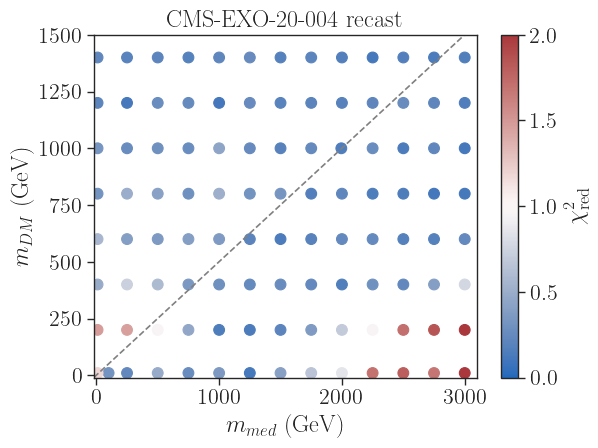

In [34]:
# Plot results
plt.scatter(x=masspts['$m_{med}$'], y=masspts['$m_{DM}$'],vmin=0., vmax=2., c=reducedChis, 
            cmap=plt.colormaps.get_cmap('vlag'), s=60)

plt.axline((1, 1), slope=1/2, linestyle='--', color='gray')

cbar=plt.colorbar(label=r'$\chi^{2}_{\rm red}$')
plt.xlabel(r'$m_{med}$ (GeV)')
plt.xlim(-20,3100)
plt.ylabel(r'$m_{DM}$ (GeV)')
plt.ylim(-10,1500)
plt.title('CMS-EXO-20-004 recast')
plt.tight_layout()

plt.savefig('chired_pseudo_scalar-cms.png')
plt.show()

/tmp/ipykernel_49000/122412841.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=plt.cm.get_cmap('Reds'), s=60)
/tmp/ipykernel_49000/122412841.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=plt.cm.get_cmap('Reds'), s=60)


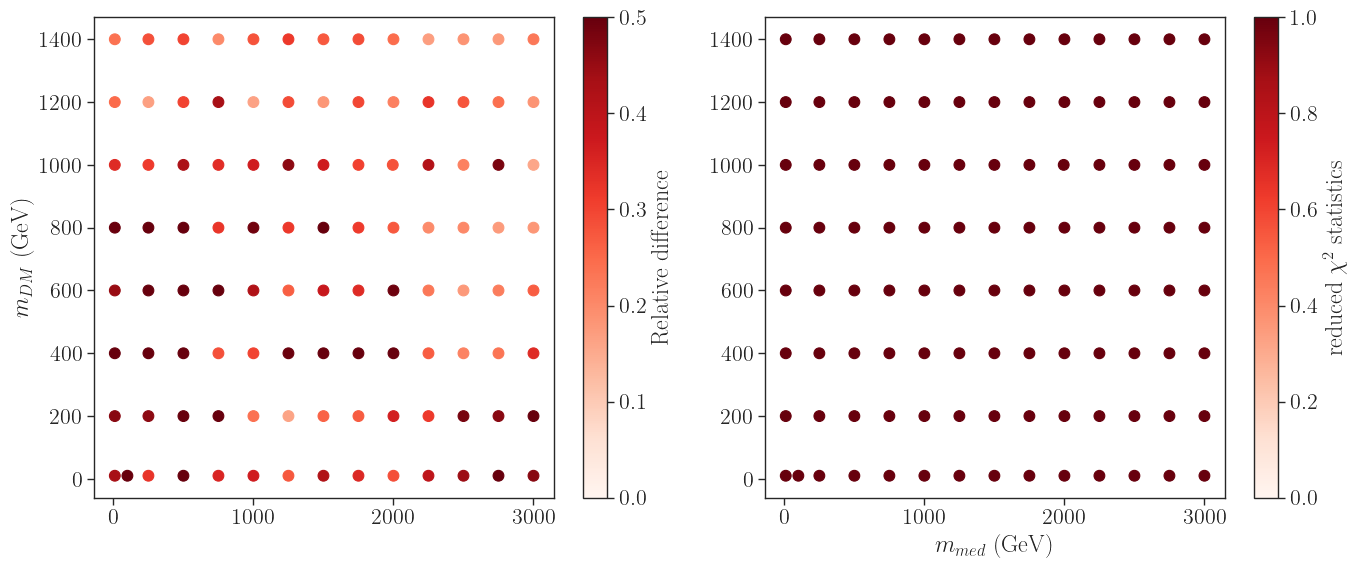

In [32]:
fig,ax = plt.subplots(figsize=(14,6),ncols=2,nrows=1)

p1 = ax[0].scatter(x=masspts['$m_{med}$'], y=masspts['$m_{DM}$'], vmin=0., vmax=.5, c=maxDiff, 
            cmap=plt.cm.get_cmap('Reds'), s=60)

p2 = ax[1].scatter(x=masspts['$m_{med}$'], y=masspts['$m_{DM}$'], vmin=0., vmax=1., c=chis, 
             cmap=plt.cm.get_cmap('Reds'), s=60)

ax[0].set_ylabel(r'$m_{DM}$ (GeV)')
ax[1].set_xlabel(r'$m_{med}$ (GeV)')

cbar1 = plt.colorbar(p1, label='Relative difference', ax=ax[0])
cbar2 = plt.colorbar(p2, label=r'reduced $\chi^{2}$ statistics', ax=ax[1])
plt.tight_layout()
plt.show()

NameError: name 'pts' is not defined

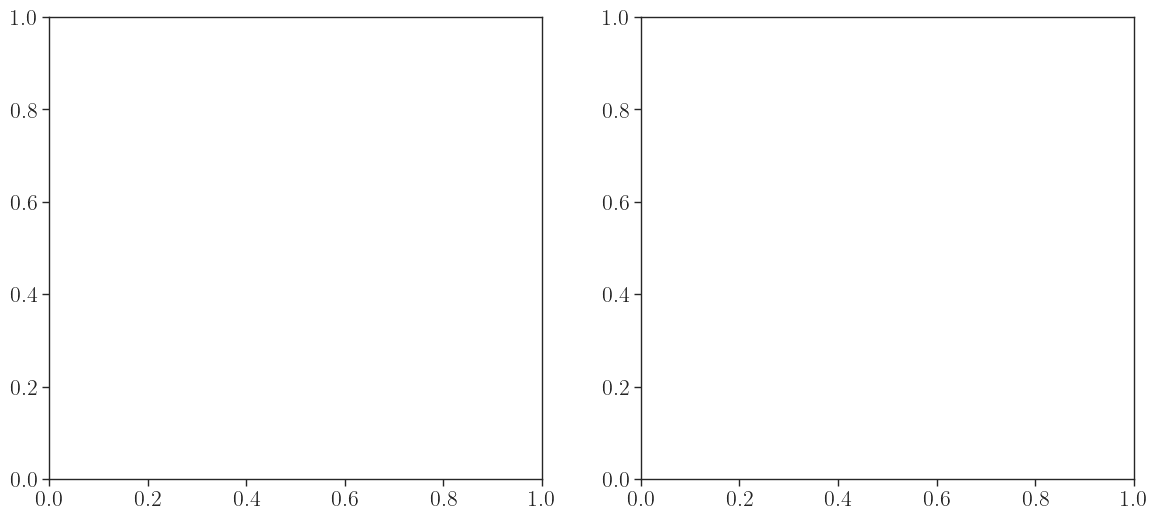

In [33]:
fig,ax = plt.subplots(figsize=(14,6),ncols=2,nrows=1)

p1 = ax[0].scatter(x=pts[:,0], y=pts[:,1], vmin=0., vmax =1., c=relDiffPts, cmap=plt.cm.get_cmap('Reds'))
# ax[0].axline((1, 1), slope=1/2, linestyle='--', color='gray')

p2 = ax[1].scatter(x=ptsChi[:,0], y=ptsChi[:,1], vmin=0., vmax =1., c=chisPts, cmap=plt.cm.get_cmap('Reds'))

ax[0].set_ylabel(r'$m_{DM}$ (GeV)')
ax[1].set_xlabel(r'$m_{med}$ (GeV)')

cbar1 = plt.colorbar(p1, label='Relative difference', ax=ax[0])
cbar2 = plt.colorbar(p2, label=r'reduced $\chi^{2}$ statistics', ax=ax[1])
plt.tight_layout()
plt.show()

In [12]:
3.130131e+02/3000

0.1043377